In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'          # or 'sans-serif', 'monospace', etc.
plt.rcParams['font.serif'] = ['Computer Modern Serif']  # You can specify specific fonts

import matplotlib.cm as cm
import matplotlib.colors as colors
import jax.random as random
import jax
import jax.numpy as jnp

import sys
sys.path.append("/home/s2421480/Documents/PhD_first_year/Extended_summer_project/Codes/d3s/")
import ranndy_jax
import importlib
importlib.reload(ranndy_jax)
from ranndy_jax import RaNNDy
import d3s.domain as domain
import d3s.observables as observables
plt.ion()

## Quantum Harmonic Oscillator

In [2]:
## Data

# domain
bounds = jnp.array([[-5, 5]])
boxes = jnp.array([500])
Omega = domain.discretization(bounds, boxes)
c = jnp.array(Omega.midpointGrid(), dtype='float64')

# system
h  = 1
m0 = 1
omega = 1
dimension = Omega.dimension()

#potential qho
def c0(x):
    return m0*omega**2*x**2/2

# #potential Poschl-Teller
# def c0(x, s=1):
#     return -s*(s+1)/(2*jnp.cosh(x)**2) 

def c2(x):
    return -h**2/(2*m0)

# data
key = random.PRNGKey(seed=0)
m = 1000
X = random.uniform(key=key, shape=(1, m), minval=bounds[0][0], maxval=bounds[0][1])

/tmp/ipykernel_17180/243170509.py:7: UserWarning: Explicitly requested dtype float64 requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  c = jnp.array(Omega.midpointGrid(), dtype='float64')


## Randomized NN

In [3]:
operator = 'schrodinger'
hidden_sizes = [516]    
final_size = 10  # Output layer size
activation="tanh"  # activation function
init_weights = 'lecun_normal'  # Initialization of weights
init_bias = 'uniform'  # Initialization of weights and biases
init_weights_std = 1.0  # Standard deviation for normal initialization
init_bias_std = 2  # Scale for uniform initialization
# direct_link=False  # Whether to use direct link to input # TODO:
random_state=0  # Random state for reproducibility
n_eigfuncs = 10  # Number of eigenfunctions to compute
kwargs = {'c0': c0, 'c2': c2} # only needed for Hamiltonian operator
domain_eigf = Omega.midpointGrid()


ranndy = RaNNDy(
    X=X,
    operator=operator,
    hidden_sizes=hidden_sizes,
    final_size=final_size,
    activation=activation,
    init_weights_dist=init_weights, 
    init_weights_std=init_weights_std,
    init_bias_dist=init_bias,
    init_bias_std=init_bias_std,
    #direct_link=direct_link,
    random_state=random_state,
    vampnet=False
)

In [4]:
# eigvals and eigenvectors approximation
eigvals, eigvecs = ranndy.operator_eig_decomp(
    X=X,
    Y=None,
    Z=None,
    params=None,
    n=n_eigfuncs,
    epsilon=1e-5,
    **kwargs)

eigfuncs = ranndy.eigenfunctions(
    eigvecs=eigvecs,
    domain=domain_eigf,
    )

In [5]:
eigvals

Array([1.0872369e+01+0.j, 9.8666010e+00+0.j, 8.2636032e+00+0.j,
       7.2575965e+00+0.j, 4.8995419e+00+0.j, 3.7024615e+00+0.j,
       2.6362491e+00+0.j, 1.5274079e+00+0.j, 5.0759369e-01+0.j,
       4.9768342e-04+0.j], dtype=complex64)

In [6]:

ind, = np.where((jnp.real(eigvals)) > 0.1)
ind = np.sort(ind)[::-1]

eigvals = eigvals[ind]

eigvals = jnp.sort(jnp.round(jnp.real(eigvals), 2))

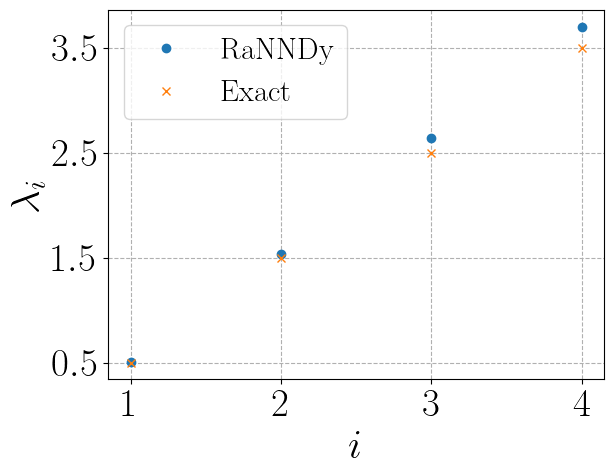

In [ ]:


plt.figure()
xv = jnp.linspace(1, 4, 4)
exact_eig = [omega*(i + 1/2) for i in range(4)]
plt.plot(xv, eigvals[:4], 'o', label='RaNNDy')
plt.plot(xv, exact_eig, 'x', label='Exact')
plt.legend(fontsize=22)
plt.grid(which='major', linestyle='--')
plt.xlabel(r'$i$', fontsize=30)
plt.ylabel(r'$\lambda_i$', fontsize=30)
plt.xticks(xv, fontsize=28)
plt.yticks(np.arange(0.5, 4, 1), fontsize=28)
plt.show()

In [8]:
from scipy.special import hermite, factorial
from math import pi, sqrt

# Generate functions for n = 0 to 4
def generate_wavefunctions(x_vals, k, omega=1.0):
    def psi_n(x, n, omega=1.0):
        Hn = hermite(n)
        prefactor = (sqrt(omega) / (pi**0.5 * 2**n * factorial(n)))**0.5
        argument = sqrt(omega) * x
        return prefactor * np.exp(-0.5 * omega * x**2) * Hn(argument)
    return [psi_n(x_vals, n, omega) for n in range(k)]

true_eigf_qho = np.array(generate_wavefunctions(domain_eigf.squeeze(), 5, omega=omega))


In [9]:

for i in range(5):
    V_exact = true_eigf_qho[-(i+1), :]
    V_1 = eigfuncs[ind[i],:]
    V_2 = -eigfuncs[ind[i],:]
    e1 = np.linalg.norm(V_exact-V_1)
    e2 = np.linalg.norm(V_exact-V_2)
    if i == 2:
        eigfuncs = eigfuncs.at[ind[i],:].set(eigfuncs[ind[i],:])
    elif e1 > e2:
        eigfuncs = eigfuncs.at[ind[i],:].set(-eigfuncs[ind[i],:])
    

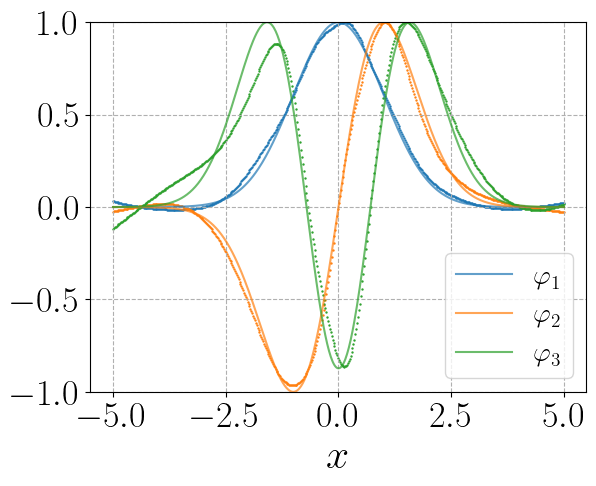

In [ ]:
markers_exact = ['x', 'x', 'x', 'x', 'x']  # Define marker style for exact eigenfunctions
markers_approx = ['o', 'o', 'o', 'o', 'o']  # Define marker style for approximated eigenfunctions
colors_ = ['r', 'g', 'b', 'c', 'm']  # Define colors for each eigenfunction

fig, ax = plt.subplots()
for i in range(3):#ind[-5:]: #range(ind):
    
    plt.scatter(domain_eigf, np.real(eigfuncs[ind[i],:]/np.amax(abs(eigfuncs[ind[i],:]))), s=0.5, marker=markers_approx[i]) #'RaNNDy' if i == 0 else None)
    plt.plot(domain_eigf.squeeze(), np.real(true_eigf_qho[i,:]/np.amax(abs(true_eigf_qho[i,:]))), alpha=0.7, label=fr'$\varphi_{i+1}$')#, label='Exact' if i == 0 else None) #s=2.2, color=colors_[i], marker=markers_exact[i], label='Exact' if i == 0 else None)
    plt.ylim((-1, 1))
    plt.grid(which='minor', linestyle=':')
    plt.grid(which='major', linestyle='--')
    plt.xlabel('$x$', fontsize=30)
    #plt.ylabel('Eigenfunctions', fontsize=35)
    plt.legend(fontsize=20, loc='best')
    plt.xticks(np.arange(-5, 6, 2.5), fontsize=26)
    plt.yticks(np.arange(-1, 1.2, .5), fontsize=26)
    plt.show()